# Task 2.1: Subplots

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.gridspec import GridSpec

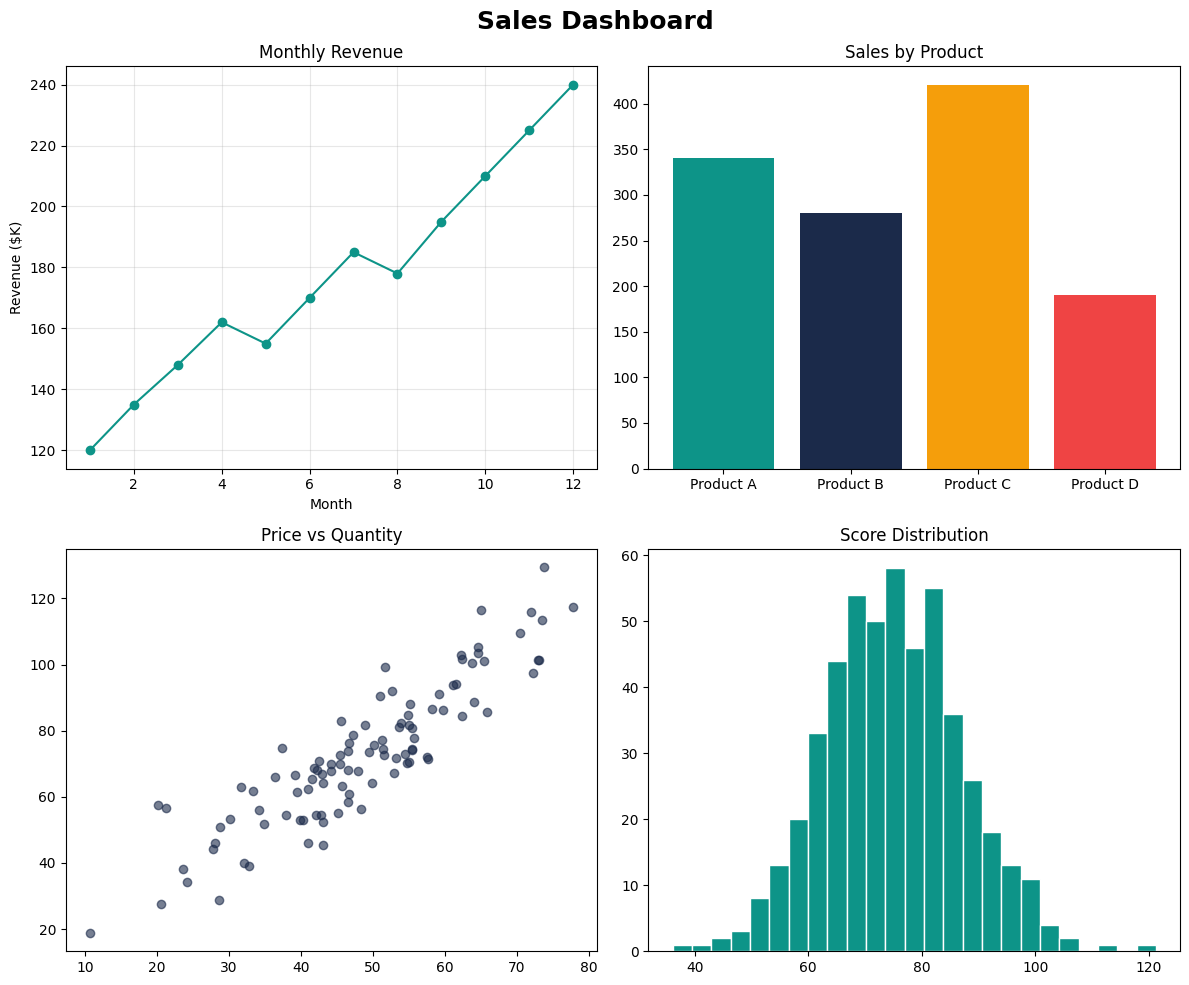

In [1]:
# Grid setup
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Sales Dashboard', fontsize=18, fontweight='bold', y=0.98)

# 1. Line Chart
months = range(1, 13)
revenue = [120, 135, 148, 162, 155, 170, 185, 178, 195, 210, 225, 240]
axes[0, 0].plot(months, revenue, marker='o', color='#0D9488')
axes[0, 0].set_title('Monthly Revenue')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Revenue ($K)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Bar Chart
cats = ['Product A', 'Product B', 'Product C', 'Product D']
vals = [340, 280, 420, 190]
axes[0, 1].bar(cats, vals, color=['#0D9488', '#1B2A4A', '#F59E0B', '#EF4444'])
axes[0, 1].set_title('Sales by Product')

# 3. Scatter Plot
np.random.seed(42)
x = np.random.normal(50, 15, 100)
y = x * 1.5 + np.random.normal(0, 10, 100)
axes[1, 0].scatter(x, y, alpha=0.6, c='#1B2A4A')
axes[1, 0].set_title('Price vs Quantity')

# 4. Histogram
data = np.random.normal(75, 12, 500)
axes[1, 1].hist(data, bins=25, color='#0D9488', edgecolor='white')
axes[1, 1].set_title('Score Distribution')

# Layout
plt.tight_layout()
plt.show()

# Task 2.2:  Custom Figure Layouts

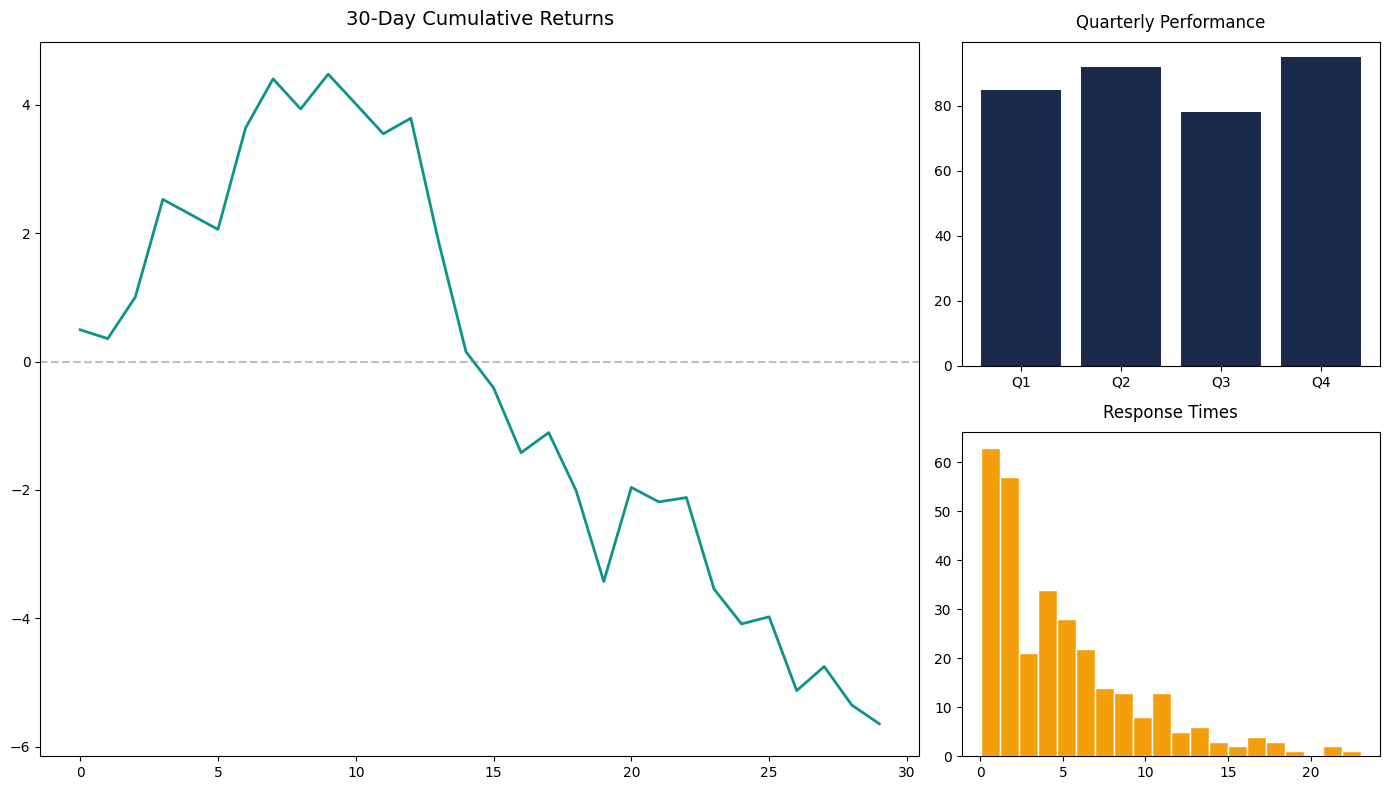

In [10]:
np.random.seed(42)

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 3, figure=fig)

# Tall chart (all rows, cols 0-1)
ax1 = fig.add_subplot(gs[:, 0:2])
ax1.plot(range(30), np.cumsum(np.random.randn(30)), linewidth=2, color='#0D9488')
ax1.set_title('30-Day Cumulative Returns', fontsize=14, pad=12)
ax1.axhline(0, color='grey', linestyle='--', alpha=0.5)

# Top right chart (row 0, col 2)
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(['Q1', 'Q2', 'Q3', 'Q4'], [85, 92, 78, 95], color='#1B2A4A')
ax2.set_title('Quarterly Performance', pad=10)

# Bottom right chart (row 1, col 2)
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(np.random.exponential(5, 300), bins=20, color='#F59E0B', edgecolor='white')
ax4.set_title('Response Times', pad=10)

plt.tight_layout()
plt.show()

# Task 2.3:  Annotations & Text

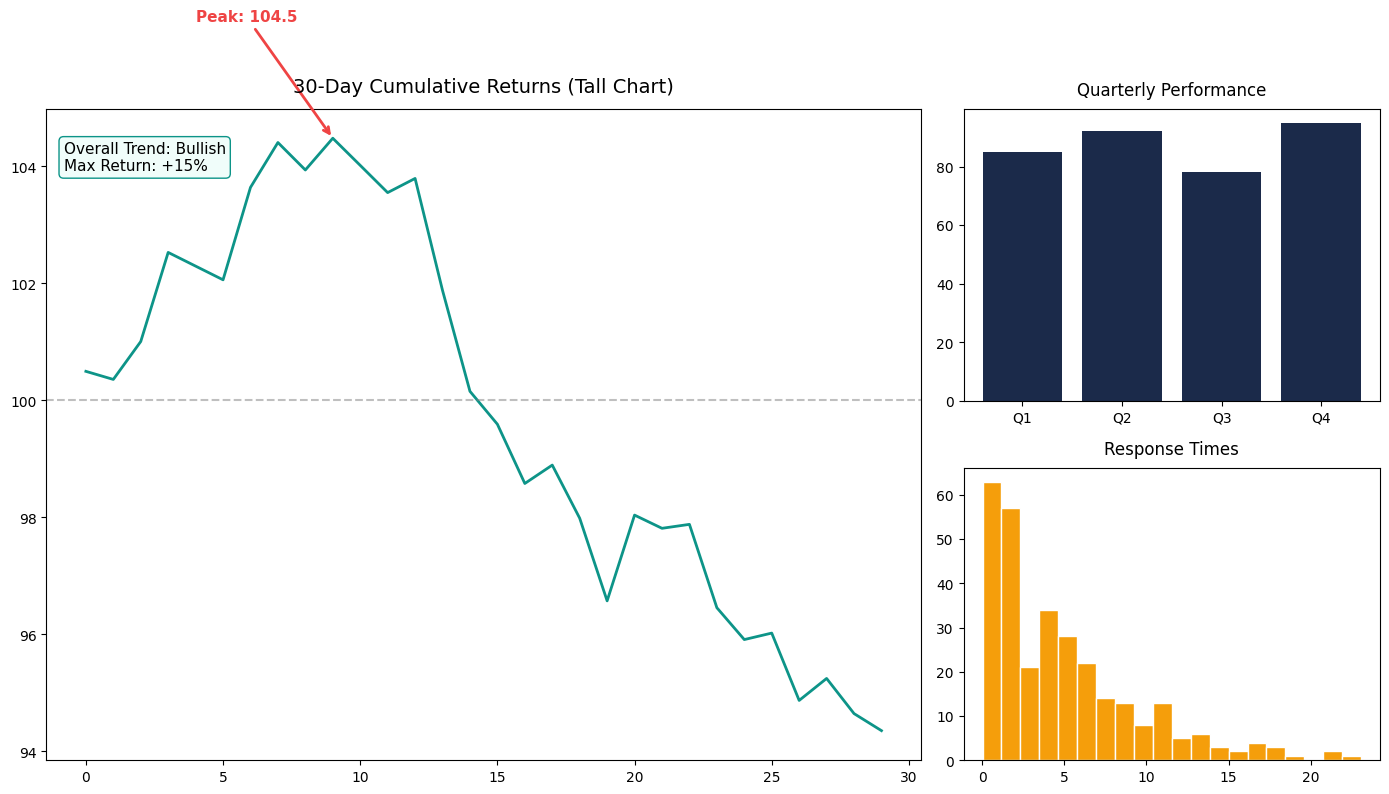

In [14]:
np.random.seed(42)

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 3, figure=fig)

# 1. Tall chart (all rows, cols 0-1)
ax1 = fig.add_subplot(gs[:, 0:2])
revenue = np.cumsum(np.random.randn(30)) + 100  # Added baseline for realistic values
ax1.plot(range(30), revenue, linewidth=2, color='#0D9488')
ax1.set_title('30-Day Cumulative Returns (Tall Chart)', fontsize=14, pad=12)
ax1.axhline(100, color='grey', linestyle='--', alpha=0.5)

# --- CHECKLIST MODIFICATIONS ON TALL CHART ---

# Modification 1: Arrow pointing to peak value (Uses Data Coordinates)
max_idx = np.argmax(revenue)
max_val = revenue[max_idx]
ax1.annotate(f'Peak: {max_val:.1f}',
             xy=(max_idx, max_val),
             xytext=(max_idx - 5, max_val + 2),
             fontsize=11, fontweight='bold', color='#EF4444',
             arrowprops=dict(arrowstyle='->', color='#EF4444', lw=2))

# Modification 2: Summary text box (Uses Axes Coordinates via transform=ax1.transAxes)
# This box stays fixed at top-left (2% from left, 95% from bottom) regardless of data scale
ax1.text(0.02, 0.95, 'Overall Trend: Bullish\nMax Return: +15%', transform=ax1.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#F0FDFA', edgecolor='#0D9488'))

# ---------------------------------------------

# 2. Top right chart (row 0, col 2)
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(['Q1', 'Q2', 'Q3', 'Q4'], [85, 92, 78, 95], color='#1B2A4A')
ax2.set_title('Quarterly Performance', pad=10)

# 3. Bottom right chart (row 1, col 2)
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(np.random.exponential(5, 300), bins=20, color='#F59E0B', edgecolor='white')
ax4.set_title('Response Times', pad=10)

plt.tight_layout()
plt.show()

# Task 2.4:  Styling & Themes

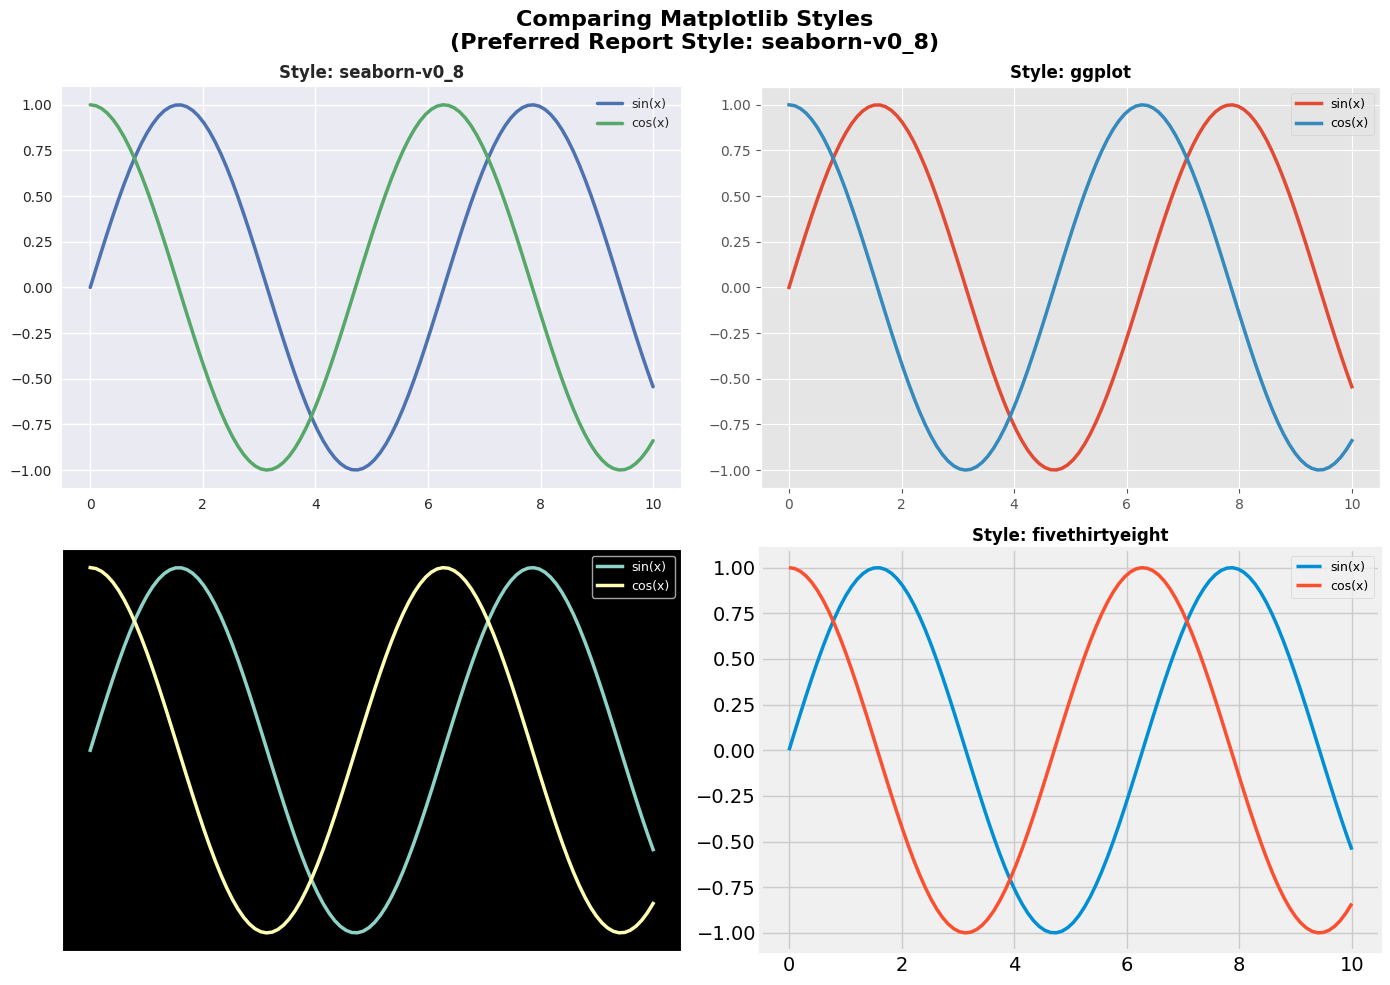

In [19]:
# 1. Compare 4 different styles
styles_to_try = ['seaborn-v0_8', 'ggplot', 'dark_background', 'fivethirtyeight']

# Create a blank figure
fig = plt.figure(figsize=(14, 10))
x = np.linspace(0, 10, 100)

# 2. Loop and create subplots inside plt.style.context() for temporary styling
for i, style_name in enumerate(styles_to_try, 1):
    with plt.style.context(style_name):
        # Subplot is created here to correctly inherit backgrounds and grids
        ax = fig.add_subplot(2, 2, i)

        ax.plot(x, np.sin(x), label='sin(x)', linewidth=2.5)
        ax.plot(x, np.cos(x), label='cos(x)', linewidth=2.5)
        ax.set_title(f'Style: {style_name}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)

# 3. Highlight the preferred style for reports (seaborn-v0_8)
plt.suptitle('Comparing Matplotlib Styles\n(Preferred Report Style: seaborn-v0_8)',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

# Task 2.5:  Pie Charts & Donut Charts

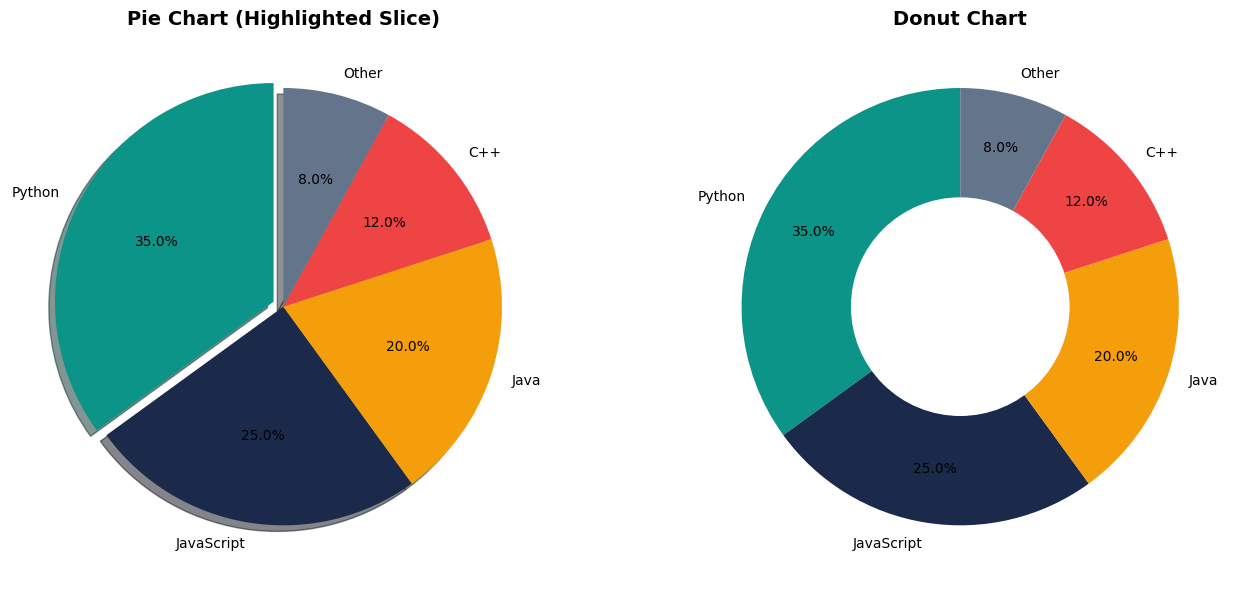

In [21]:
# Ensure the output directory exists so saving doesn't fail
os.makedirs('week2', exist_ok=True)

# Data
labels = ['Python', 'JavaScript', 'Java', 'C++', 'Other']
sizes = [35, 25, 20, 12, 8]
colors = ['#0D9488', '#1B2A4A', '#F59E0B', '#EF4444', '#64748B']

# Modification 1: Use explode to highlight the Python slice (0.05)
explode = (0.05, 0, 0, 0, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Modification 2: Create Standard Pie Chart
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors,
        explode=explode, shadow=True, startangle=90)
ax1.set_title('Pie Chart (Highlighted Slice)', fontsize=14, fontweight='bold')

# Modification 3: Create Donut Chart
wedges, texts, autotexts = ax2.pie(sizes, labels=labels, autopct='%1.1f%%',
                                  colors=colors, pctdistance=0.75, startangle=90)

# Add center white circle for the donut hole
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Donut Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()